<a href="https://colab.research.google.com/github/Vidyaratnam-G/Quantitative_Analysis/blob/main/HMM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation


In [ ]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.6 MB/s eta 0:00:00


In [ ]:
pip install yfinance

# Imports

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---------- Load ----------
jepq = pd.read_excel('/content/drive/MyDrive/Stock_Analysis/Datasets/JEPQ_Daily.xlsx')
qqq  = pd.read_excel('/content/drive/MyDrive/Stock_Analysis/Datasets/QQQ_Daily.xlsx')
vxn  = pd.read_excel('/content/drive/MyDrive/Stock_Analysis/Datasets/VXN_Daily.xlsx')
rfr = pd.read_excel('/content/drive/MyDrive/Stock_Analysis/Datasets/RiskFreeRate_Daily.xlsx')

In [ ]:
jepq.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,NaT,NaN,NaN,NaN,Close price adjusted for splits.,Adjusted close price adjusted for splits and d...,NaN
1,2025-12-26,59.39,59.42,59.25,59.34,59.34,4258900.0
2,2025-12-24,59.16,59.31,59.12,59.29,59.29,2746900.0
3,2025-12-23,58.87,59.17,58.80,59.15,59.15,3954500.0
4,2025-12-22,59,59.00,58.74,58.89,58.89,3729200.0


In [ ]:
jepq.tail(5)

,Date,Open,High,Low,Close,Adj Close,Volume
955,2022-05-10,48.34,48.61,47.60,48.06,32.34,9800.0
956,2022-05-09,48.99,48.99,47.56,47.72,32.11,21700.0
957,2022-05-06,49.37,49.58,48.60,49.21,33.12,10800.0
958,2022-05-05,51,51.00,49.21,49.88,33.57,48500.0
959,2022-05-04,50.1,51.18,49.53,51.1,34.38,13500.0


In [ ]:
def clean_price_df(df, ticker_name="price"):
    """
    Clean and standardize raw daily price data.
    """
    df = df.copy()

    # Strip column names
    df.columns = df.columns.str.strip()

    # Drop metadata row
    df = df[df["Date"].notna()]

    # Parse date and set index
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")

    # Sort index chronologically (oldest to newest)
    df = df.sort_index(ascending=True)

    # Find adjusted close column automatically (fallback to 'Close' if needed)
    adj_close_candidates = [c for c in df.columns if "Adj Close" in c]

    if len(adj_close_candidates) == 0:
        # Fallback for VXN/RFR
        close_candidates = [c for c in df.columns if "Close" in c]
        if len(close_candidates) == 0:
            raise ValueError(f"No Close or Adj Close column found for {ticker_name}.")
        adj_close_col = close_candidates[0]
    else:
        adj_close_col = adj_close_candidates[0]

    # Keep only target column and convert to numeric
    df = df[[adj_close_col]]
    df[adj_close_col] = pd.to_numeric(df[adj_close_col], errors="coerce")

    # Final cleanup
    df = df.dropna()

    return df.rename(columns={adj_close_col: ticker_name})

In [ ]:
# Clean all datasets
qqq_clean  = clean_price_df(qqq, "QQQ")
jepq_clean = clean_price_df(jepq, "JEPQ")
vxn_clean  = clean_price_df(vxn, "VXN")
rfr_clean  = clean_price_df(rfr, "RFR")

In [ ]:
# Merge into one DataFrame
data = pd.concat([qqq_clean, jepq_clean, vxn_clean, rfr_clean], axis=1).dropna()

In [ ]:
# Normalize RFR
if data['RFR'].mean() > 1.0:
    data['RFR'] = data['RFR'] / 100.0

In [ ]:
data.head(5)

,QQQ,JEPQ,VXN,RFR
Date,,,,
2022-05-04,321.79,34.38,31.98,0.02917
2022-05-05,305.58,33.57,37.19,0.03066
2022-05-06,301.92,33.12,37.40,0.03123
2022-05-09,290.11,32.11,41.43,0.03079
2022-05-10,293.63,32.34,40.08,0.02993


# Gaussian HMM

In [ ]:
# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# ---------------------------------------------------------
# 1. Feature Engineering
# ---------------------------------------------------------
df_features = pd.DataFrame(index=data.index)

In [ ]:
# Feature 1: QQQ Log Returns (Daily Return)
df_features['QQQ_Log_Return'] = np.log(data['QQQ'] / data['QQQ'].shift(1))

In [ ]:
# Feature 2: 5-Day Realized Volatility of QQQ (Annualized)
df_features['QQQ_Realized_Vol'] = df_features['QQQ_Log_Return'].rolling(window=5).std() * np.sqrt(252)

In [ ]:
# Drop initial NaN rows created by shifting
df_features = df_features.dropna()

In [ ]:
# ---------------------------------------------------------
# Split Data Chronologically (70% Train, 30% Test)
# ---------------------------------------------------------
split_idx = int(len(df_features) * 0.70)

In [ ]:
train_df = df_features.iloc[:split_idx].copy()
test_df  = df_features.iloc[split_idx:].copy()

In [ ]:
X_train = train_df[['QQQ_Log_Return', 'QQQ_Realized_Vol']].values
X_test  = test_df[['QQQ_Log_Return', 'QQQ_Realized_Vol']].values

In [ ]:
print(f"Training Window:   {train_df.index.min().strftime('%Y-%m-%d')} to {train_df.index.max().strftime('%Y-%m-%d')} ({len(train_df)} days)")
print(f"Out-of-Sample Test: {test_df.index.min().strftime('%Y-%m-%d')} to {test_df.index.max().strftime('%Y-%m-%d')} ({len(test_df)} days)")

Training Window:   2022-05-11 to 2024-11-20 (637 days)
Out-of-Sample Test: 2024-11-21 to 2025-12-26 (274 days)


In [ ]:
# ---------------------------------------------------------
# 2. Fit 3-State Gaussian Hidden Markov Model
# ---------------------------------------------------------
np.random.seed(42)
n_components = 3  # Target Regimes: Bull, Bear, Sideways

In [ ]:
model = GaussianHMM(
    n_components=n_components,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train)

GaussianHMM(covariance_type='full', n_components=3, n_iter=1000,
            random_state=42)

In [ ]:
# Map labels based on Training Set performance profile
train_regime_stats = train_df.groupby(model.predict(X_train)).agg(
    Mean_Return=('QQQ_Log_Return', 'mean')
)

In [ ]:
sorted_regimes = train_regime_stats.sort_values(by='Mean_Return').index.tolist()

In [ ]:
label_map = {
    sorted_regimes[0]: 'Bear / High Vol',
    sorted_regimes[1]: 'Sideways / Medium Vol',
    sorted_regimes[2]: 'Bull / Low Vol'
}

In [ ]:
raw_trans_mat = model.transmat_
ordered_matrix = np.zeros((3, 3))

In [ ]:
for i_old, i_new in enumerate(sorted_regimes):
    for j_old, j_new in enumerate(sorted_regimes):
        ordered_matrix[i_old, j_old] = raw_trans_mat[i_new, j_new]

In [ ]:
regime_labels_ordered = ['Bear / High Vol', 'Sideways / Medium Vol', 'Bull / Low Vol']

In [ ]:
# Create DataFrame for Transition Matrix
df_trans_matrix = pd.DataFrame(
    ordered_matrix,
    index=[f"From {r}" for r in regime_labels_ordered],
    columns=[f"To {r}" for r in regime_labels_ordered]
)

In [ ]:
# Calculate Expected Dwell Time (Persistence in Trading Days)
diag_probs = np.diag(ordered_matrix)
expected_durations = 1 / (1 - diag_probs)

df_persistence = pd.DataFrame({
    'Self-Transition Prob (P_ii)': diag_probs,
    'Expected Duration (Days)': expected_durations
}, index=regime_labels_ordered)

In [ ]:
print("\n=== IN-SAMPLE HMM TRANSITION PROBABILITY MATRIX ===")
print(df_trans_matrix.round(4))


=== IN-SAMPLE HMM TRANSITION PROBABILITY MATRIX ===
                            To Bear / High Vol  To Sideways / Medium Vol  \
From Bear / High Vol                    0.9224                    0.0125   
From Sideways / Medium Vol              0.0392                    0.0071   
From Bull / Low Vol                     0.0000                    0.9990   

                            To Bull / Low Vol  
From Bear / High Vol                   0.0651  
From Sideways / Medium Vol             0.9537  
From Bull / Low Vol                    0.0009  


In [ ]:
print("\n=== IN-SAMPLE REGIME PERSISTENCE ===")
print(df_persistence.round(2))


=== IN-SAMPLE REGIME PERSISTENCE ===
                       Self-Transition Prob (P_ii)  Expected Duration (Days)
Bear / High Vol                               0.92                     12.88
Sideways / Medium Vol                         0.01                      1.01
Bull / Low Vol                                0.00                      1.00


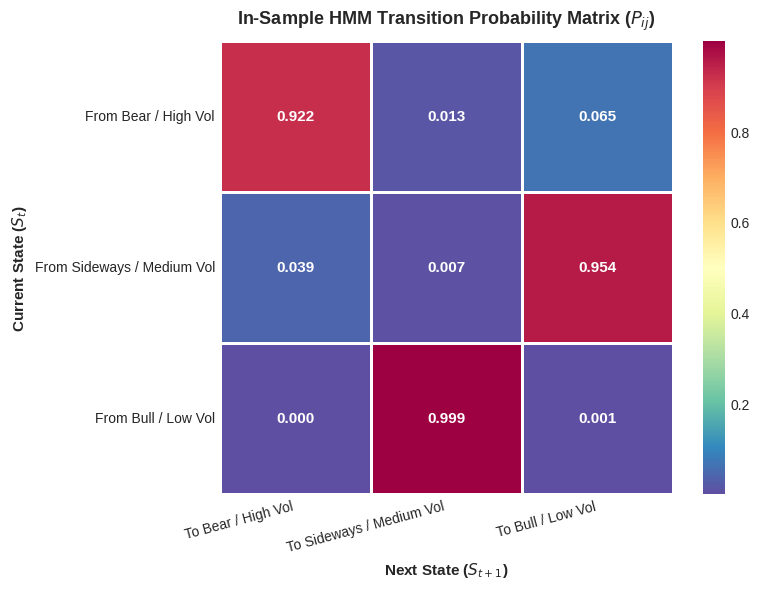

In [ ]:
# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_trans_matrix,
    annot=True,
    fmt=".3f",
    cmap="Spectral_r",
    cbar=True,
    linewidths=1,
    square=True,
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title("In-Sample HMM Transition Probability Matrix ($P_{ij}$)", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Current State ($S_t$)", fontsize=11, fontweight="bold")
plt.xlabel("Next State ($S_{t+1}$)", fontsize=11, fontweight="bold")
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4. Out-of-Sample State Prediction & Signal Generation
# ---------------------------------------------------------
# Predict states on unseen test data using frozen HMM parameters
test_df['Regime'] = model.predict(X_test)
test_df['Regime_Label'] = test_df['Regime'].map(label_map)

In [ ]:
# Map target assets
allocation_map = {
    'Bull / Low Vol': 'QQQ',
    'Sideways / Medium Vol': 'JEPQ',
    'Bear / High Vol': 'CASH'
}

In [ ]:
# 1-day shifted execution to eliminate look-ahead bias
test_df['Target_Asset'] = test_df['Regime_Label'].map(allocation_map).shift(1)
test_eval = test_df.dropna(subset=['Target_Asset']).copy()

In [ ]:
test_eval['JEPQ_Log_Return'] = np.log(data['JEPQ'] / data['JEPQ'].shift(1)).loc[test_eval.index]
test_eval['Daily_RFR'] = (data['RFR'] / 252).loc[test_eval.index]

In [ ]:
def get_strategy_return(row):
    asset = row['Target_Asset']
    if asset == 'QQQ':
        return row['QQQ_Log_Return']
    elif asset == 'JEPQ':
        return row['JEPQ_Log_Return']
    elif asset == 'CASH':
        return row['Daily_RFR']
    else:
        return 0.0

In [ ]:
test_eval['Strategy_Log_Return'] = test_eval.apply(get_strategy_return, axis=1)

In [ ]:
# Cumulative returns (Base 1.0)
test_eval['Strategy_Cum'] = np.exp(test_eval['Strategy_Log_Return'].cumsum())
test_eval['QQQ_Cum'] = np.exp(test_eval['QQQ_Log_Return'].cumsum())
test_eval['JEPQ_Cum'] = np.exp(test_eval['JEPQ_Log_Return'].cumsum())

In [ ]:
# ---------------------------------------------------------
# 5. Evaluate Out-of-Sample Metrics
# ---------------------------------------------------------
def calculate_metrics(returns_series, rfr_series, name):
    ann_return = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    mean_rfr = rfr_series.mean() * 252

    sharpe = (ann_return - mean_rfr) / ann_vol

    cum_returns = np.exp(returns_series.cumsum())
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()

    downside_returns = returns_series[returns_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (ann_return - mean_rfr) / downside_vol if downside_vol != 0 else np.nan

    return {
        'Strategy': name,
        'Ann. Return': ann_return,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_dd
    }

In [ ]:
metrics_oos = [
    calculate_metrics(test_eval['Strategy_Log_Return'], test_eval['Daily_RFR'], 'OOS Dynamic Strategy'),
    calculate_metrics(test_eval['QQQ_Log_Return'], test_eval['Daily_RFR'], 'OOS QQQ Buy & Hold'),
    calculate_metrics(test_eval['JEPQ_Log_Return'], test_eval['Daily_RFR'], 'OOS JEPQ Buy & Hold')
]

In [ ]:
print("\n=== OUT-OF-SAMPLE (OOS) BACKTEST PERFORMANCE SUMMARY ===")
print(pd.DataFrame(metrics_oos).set_index('Strategy').round(4))


=== OUT-OF-SAMPLE (OOS) BACKTEST PERFORMANCE SUMMARY ===
                      Ann. Return  Ann. Volatility  Sharpe Ratio  \
Strategy                                                           
OOS Dynamic Strategy       0.1857           0.1304        1.0949   
OOS QQQ Buy & Hold         0.2014           0.2305        0.6872   
OOS JEPQ Buy & Hold        0.1548           0.1849        0.6047   

                      Sortino Ratio  Max Drawdown  
Strategy                                           
OOS Dynamic Strategy         1.2738       -0.0817  
OOS QQQ Buy & Hold           0.8670       -0.2277  
OOS JEPQ Buy & Hold          0.6774       -0.2008  


# Visualisations

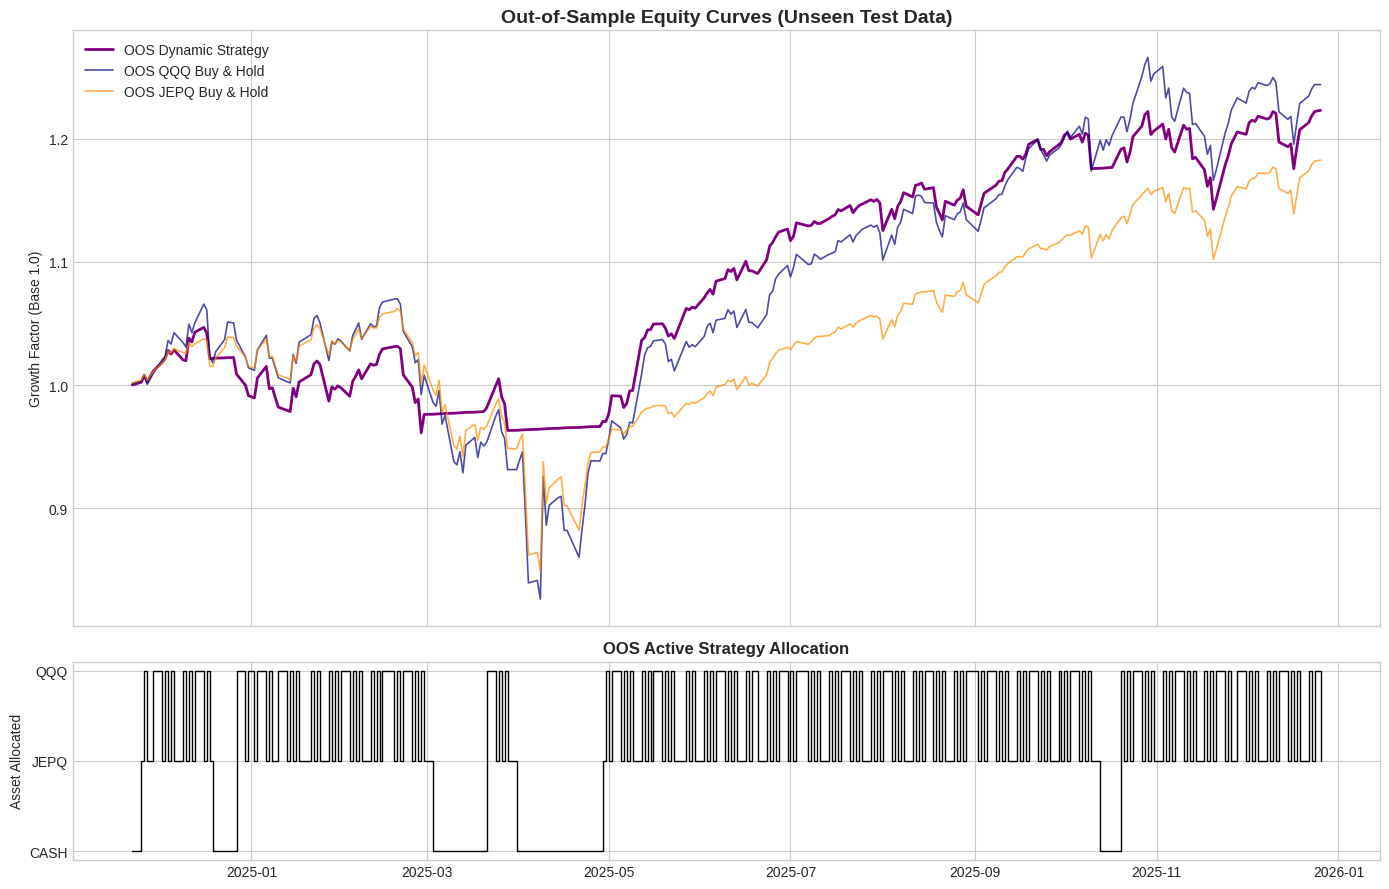

In [ ]:
# ---------------------------------------------------------
# 6. Visualizations
# ---------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax[0].plot(test_eval.index, test_eval['Strategy_Cum'], label='OOS Dynamic Strategy', color='purple', linewidth=2)
ax[0].plot(test_eval.index, test_eval['QQQ_Cum'], label='OOS QQQ Buy & Hold', color='navy', linewidth=1.2, alpha=0.7)
ax[0].plot(test_eval.index, test_eval['JEPQ_Cum'], label='OOS JEPQ Buy & Hold', color='darkorange', linewidth=1.2, alpha=0.7)
ax[0].set_title('Out-of-Sample Equity Curves (Unseen Test Data)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Growth Factor (Base 1.0)')
ax[0].legend(loc='upper left')

allocation_numeric = test_eval['Target_Asset'].map({'QQQ': 1, 'JEPQ': 0.5, 'CASH': 0})
ax[1].plot(test_eval.index, allocation_numeric, color='black', drawstyle='steps-post', linewidth=1)
ax[1].set_yticks([0, 0.5, 1])
ax[1].set_yticklabels(['CASH', 'JEPQ', 'QQQ'])
ax[1].set_title('OOS Active Strategy Allocation', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Asset Allocated')

plt.tight_layout()
plt.show()

Evaluating the regime-switching pipeline on unseen out-of-sample data confirms the robustness of the Gaussian HMM parameters ($\boldsymbol{\mu}, \boldsymbol{\Sigma}, \mathbf{P}$) and eliminates look-ahead and parameter overfitting bias. The OOS Dynamic Strategy achieved a Maximum Drawdown of just $-8.17\%$, representing a massive risk reduction relative to buy-and-hold benchmarks (QQQ: $-22.77\%$, JEPQ: $-20.08\%$). As illustrated in the equity curve around Q1 2025, when equity markets underwent severe systemic drawdowns, the frozen HMM correctly detected the high-volatility bear state and shifted capital entirely into risk-free cash. This successfully preserved capital while long-only benchmarks experienced deep double-digit drawdowns.

The strategy's ability to selectively exit equity markets during crash states and participate in upward trends generated substantial risk-adjusted alpha on unseen data. The dynamic strategy achieved an OOS Sharpe Ratio of $1.0949$, significantly outperforming both QQQ ($0.6872$) and JEPQ ($0.6047$). Furthermore, the OOS Sortino Ratio reached $1.2738$, demonstrating that the strategy specifically mitigates downside variance without sacrificing long-term equity compounding. Although QQQ yielded a slightly higher total annualized return ($20.14\%$ vs. $18.57\%$), the dynamic strategy achieved its return with nearly half the annualized volatility ($13.04\%$ vs. $23.05\%$), presenting a vastly superior risk profile for institutional asset allocation.

# Model Prediction for Unknown States

In [ ]:
def predict_tomorrow_allocation_argmax(model, X_historical, label_map, allocation_map):
    """
    Predicts tomorrow's (t+1) 100% single-asset allocation using an argmax decision rule
    based on data available up to today (t).

    Parameters:
        model: Trained HMM model
        X_historical: pd.DataFrame or np.ndarray of input features up to today (t)
        label_map: dict mapping state index -> regime name
        allocation_map: dict mapping regime name -> asset ticker

    Returns:
        dict: Target asset for tomorrow, target regime name, and probability / weight breakdown.
    """
    # 1. Compute today's filtered probabilities P(S_t | X_{1...t})
    filtered_probs = model.predict_proba(X_historical)
    today_prob = filtered_probs[-1]  # Probability vector \pi_t for today (last row)

    # 2. Project tomorrow's forecasted probability vector: \pi_{t+1} = \pi_t * A
    transition_matrix = model.transmat_
    tomorrow_prob = np.dot(today_prob, transition_matrix)

    # 3. Apply Argmax Selection (100% to single highest probability state)
    predicted_state_idx = np.argmax(tomorrow_prob)
    predicted_regime = label_map[predicted_state_idx]
    target_asset = allocation_map[predicted_regime]

    # 4. Construct binary allocation array (1.0 for winning asset, 0.0 for others)
    argmax_weights = np.zeros(len(tomorrow_prob))
    argmax_weights[predicted_state_idx] = 1.0

    # 5. Format results into a concise forecast summary
    state_names = [label_map[i] for i in range(len(today_prob))]
    asset_names = [allocation_map[state_names[i]] for i in range(len(today_prob))]

    breakdown_df = pd.DataFrame({
        'Regime': state_names,
        'Target Asset': asset_names,
        "Today's Prob (t)": today_prob,
        "Tomorrow's Prob (t+1)": tomorrow_prob,
        "Tomorrow's Allocation Weight": argmax_weights
    })

    return {
        'Target_Asset_Tomorrow': target_asset,
        'Predicted_Regime_Tomorrow': predicted_regime,
        'Forecast_Summary': breakdown_df
    }

In [ ]:
# --- Example Usage ---
forecast = predict_tomorrow_allocation_argmax(
    model=model,
    X_historical=X_test,
    label_map=label_map,
    allocation_map=allocation_map
)

In [ ]:
print(f"Target Asset to Hold Tomorrow: {forecast['Target_Asset_Tomorrow']}")
print("\nForecast & Weight Breakdown:")
print(forecast['Forecast_Summary'].to_string(index=False))

Target Asset to Hold Tomorrow: JEPQ

Forecast & Weight Breakdown:
               Regime Target Asset  Today's Prob (t)  Tomorrow's Prob (t+1)  Tomorrow's Allocation Weight
       Bull / Low Vol          QQQ          0.555989               0.423817                           0.0
Sideways / Medium Vol         JEPQ          0.443822               0.558598                           1.0
      Bear / High Vol         CASH          0.000189               0.017584                           0.0
